# Task 3: Viscoelasticity

Modellierung viskoelastischen Materialverhaltens mit Recurrent Neural Networks (RNNs).

**Maxwell-Element Parameter:** $\{E^\infty, E, \eta\} = \{0.5, 2, 1\}$

**Lastfälle:** $(A, \omega) \in \{(1,1), (1,2), (2,3)\}$

**Modelle:**
1. Simple RNN (naiv, ohne Physik)
2. Maxwell-Modell (analytisch + trainierbare Evolutionsgleichung)
3. GSM-Modell (Generalized Standard Materials)

# NUR FÜR ALEX WEGEN VENV UNTERSCHIED

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

candidates = [
    cwd / "src",                          # if cwd == viscoelasticity/
    cwd / "viscoelasticity" / "src",      # if cwd == workspace root
]

src_path = next((p for p in candidates if p.exists()), None)

if src_path is None:
    raise FileNotFoundError(
        "Could not find the 'src' directory. Tried:\n" +
        "\n".join(str(p) for p in candidates) +
        f"\nCurrent working directory is: {cwd}"
    )

sys.path.insert(0, str(src_path))
print("Added to sys.path:", src_path)


Added to sys.path: C:\Users\alexp\Desktop\#Uni\Master 1\5. Semester\PAML Tutorium\Repo\ML-Tutorial-WS25_26\viscoelasticity\src


In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import klax
import numpy as np
import time
import matplotlib.pyplot as plt

import tmlsm.data as td
import tmlsm.plots as tp
import tmlsm.models as tm
from tmlsm import evaluation as ev

In [3]:
# Material parameters
E_infty = 0.5
E = 2.0
eta = 1.0
n = 100  # time steps per period

## Datengenerierung & Visualisierung

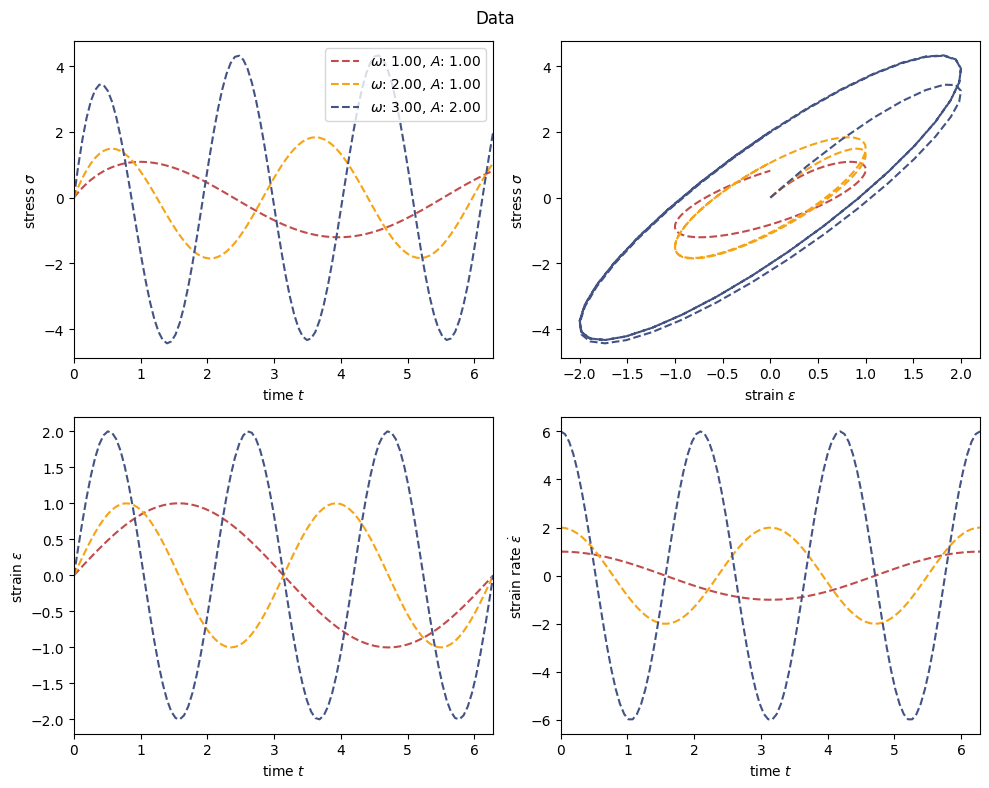

In [4]:
# All load cases
omegas_all = [1, 2, 3]
As_all = [1, 1, 2]

eps_all, eps_dot_all, sig_all, dts_all = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_all, eps_dot_all, sig_all, omegas_all, As_all)

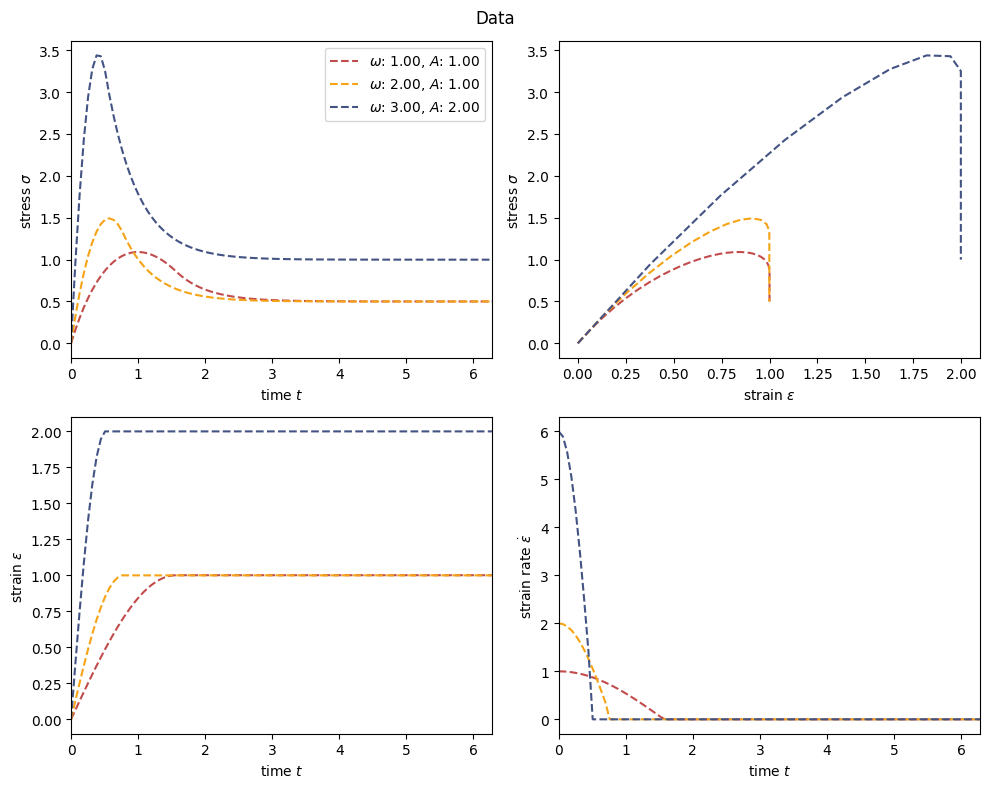

In [5]:
# Relaxation data
eps_relax, eps_dot_relax, sig_relax, dts_relax = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_relax, eps_dot_relax, sig_relax, omegas_all, As_all)

## Modell 1: Simple RNN

Naiver RNN ohne physikalische Informationen. Das Netzwerk lernt direkt die Abbildung
$(\gamma_\text{old}, \varepsilon, \Delta t) \to (\gamma_\text{new}, \sigma)$.

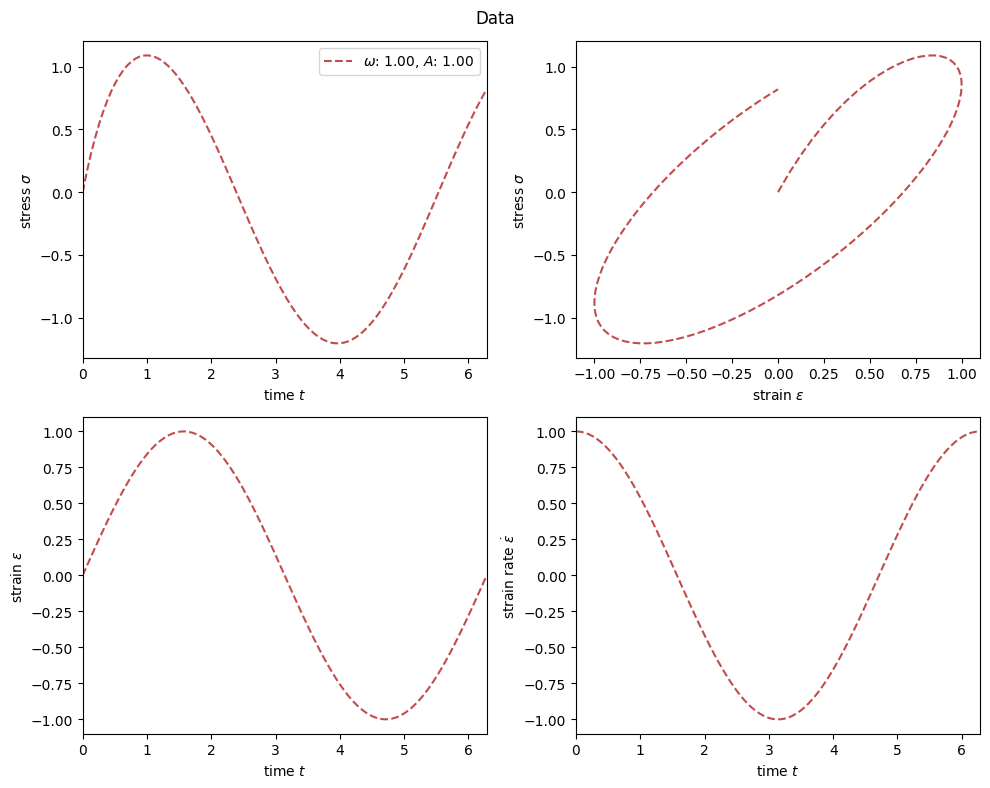

In [6]:
# Calibration data: (A=1, omega=1)
omegas_cal = [1.0]
As_cal = [1.0]

eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_cal, As_cal
)
tp.plot_data(eps_cal, eps_dot_cal, sig_cal, omegas_cal, As_cal)

Step: 0, Loss: 1.764e+00
Step: 100, Loss: 3.028e-01
Step: 200, Loss: 2.753e-01
Step: 300, Loss: 2.748e-01
Step: 400, Loss: 2.742e-01
Step: 500, Loss: 2.722e-01
Step: 600, Loss: 2.811e-01
Step: 700, Loss: 2.726e-01
Step: 800, Loss: 2.719e-01
Step: 900, Loss: 2.709e-01
Step: 1000, Loss: 2.695e-01
Step: 1100, Loss: 2.668e-01
Step: 1200, Loss: 2.599e-01
Step: 1300, Loss: 1.085e-01
Step: 1400, Loss: 1.110e-02
Step: 1500, Loss: 8.890e-03
Step: 1600, Loss: 7.047e-03
Step: 1700, Loss: 5.454e-03
Step: 1800, Loss: 4.147e-03
Step: 1900, Loss: 3.130e-03
Step: 2000, Loss: 2.372e-03
Step: 2100, Loss: 1.823e-03
Step: 2200, Loss: 1.430e-03
Step: 2300, Loss: 1.149e-03
Step: 2400, Loss: 9.440e-04
Step: 2500, Loss: 7.924e-04
Step: 2600, Loss: 6.774e-04
Step: 2700, Loss: 5.880e-04
Step: 2800, Loss: 5.166e-04
Step: 2900, Loss: 4.583e-04
Step: 3000, Loss: 4.094e-04
Step: 3100, Loss: 3.677e-04
Step: 3200, Loss: 3.312e-04
Step: 3300, Loss: 2.989e-04
Step: 3400, Loss: 2.699e-04
Step: 3500, Loss: 2.435e-04
Step

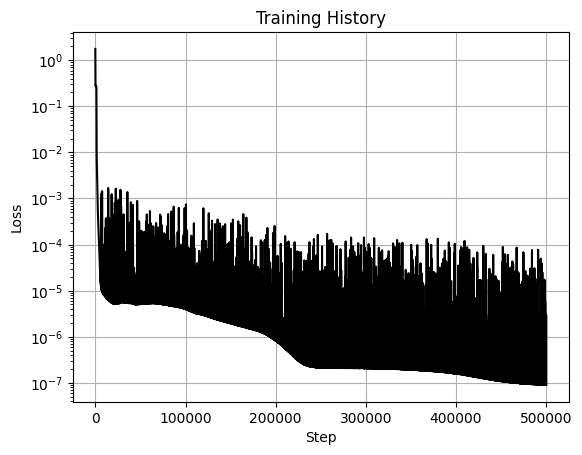

In [12]:
# Build and train Simple RNN
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_rnn = tm.build(key=keys[0])

model_rnn, history_rnn = klax.fit(
    model_rnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=500000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_rnn.plot()

In [13]:
model_rnn_ = klax.finalize(model_rnn)

### Interpolation: Test auf Trainingsdaten

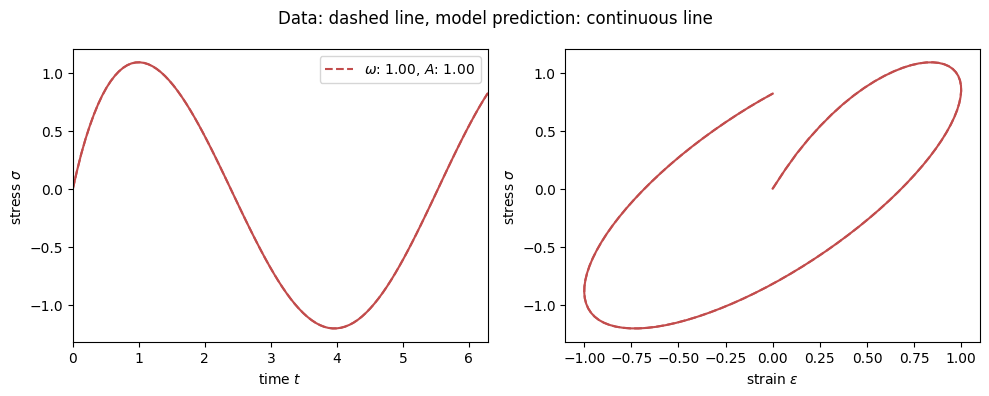

In [14]:
sig_pred = jax.vmap(model_rnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_pred, omegas_cal, As_cal)

### Extrapolation: Test auf neue Lastfälle

In [11]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3]
As_test = [1, 1, 2]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_test = jax.vmap(model_rnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_pred_test, omegas_test, As_test)

NameError: name 'model_rnn_' is not defined

In [14]:
# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_relax = jax.vmap(model_rnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_pred_relax, omegas_test, As_test)

NameError: name 'model_rnn_' is not defined

In [6]:
import tmlsm.configs as configs
import tmlsm.experiments as experiments
import tmlsm.plots as plots

Starte Sweep mit 4 Konfigurationen...

[1/4] Running experiment: lc_sweep_lc_0

Experiment: lc_sweep_lc_0
Description: Sweep loadcases (config 0)

--- simple_rnn ---
Training for 200000 steps...
Step: 0, Loss: 9.586e-01
Step: 100, Loss: 2.976e-01
Step: 200, Loss: 2.841e-01
Step: 300, Loss: 2.774e-01
Step: 400, Loss: 2.708e-01
Step: 500, Loss: 2.542e-01
Step: 600, Loss: 7.184e-02
Step: 700, Loss: 1.552e-02
Step: 800, Loss: 1.491e-02
Step: 900, Loss: 2.637e-03
Step: 1000, Loss: 1.730e-03
Step: 1100, Loss: 1.535e-03
Step: 1200, Loss: 1.398e-03
Step: 1300, Loss: 1.286e-03
Step: 1400, Loss: 1.187e-03
Step: 1500, Loss: 1.099e-03
Step: 1600, Loss: 1.018e-03
Step: 1700, Loss: 9.447e-04
Step: 1800, Loss: 8.776e-04
Step: 1900, Loss: 8.161e-04
Step: 2000, Loss: 7.598e-04
Step: 2100, Loss: 1.447e-03
Step: 2200, Loss: 6.606e-04
Step: 2300, Loss: 1.288e-03
Step: 2400, Loss: 5.759e-04
Step: 2500, Loss: 2.062e-03
Step: 2600, Loss: 5.024e-04
Step: 2700, Loss: 4.946e-04
Step: 2800, Loss: 4.378e-04
Step:

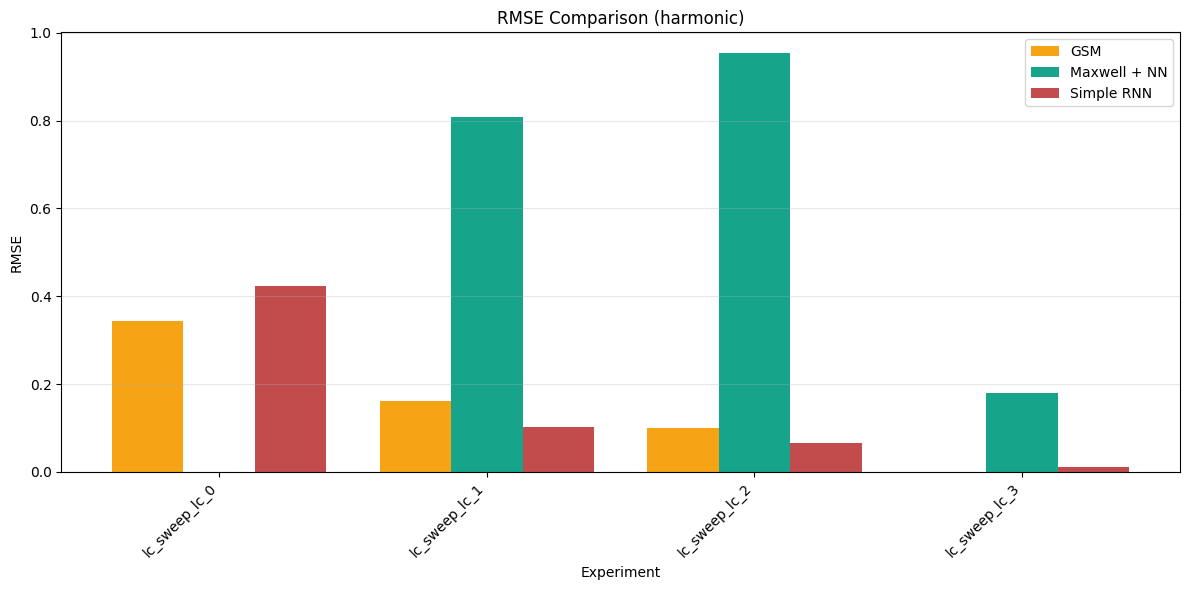

In [3]:
# Format: (Amplitude, Omega)
convex_hull_loadcases = [
    # Die 4 Ecken des Parameterraums
    (0.5, 0.5),  # Min A, Min Omega
    (0.5, 4.0),  # Min A, Max Omega
    (3.0, 0.5),  # Max A, Min Omega
    (3.0, 4.0),  # Max A, Max Omega
    
    # Ein Zentrumspunkt zur Stabilisierung (interpoliert gut)
    (1.75, 2.25) 
]

loadcase_sweep = [
    [(1.0, 1.0)],                             # Nur Basis
    [(1.0, 1.0), (3.0, 1.0)],                 # Basis + Hohe Amplitude
    [(1.0, 1.0), (2.0, 1.0), (3.0, 1.0)],     # Basis + Mittel + Hoch
    convex_hull_loadcases
]

sweep_configs = configs.generate_sweep_configs(
    param_name="train_loadcases",
    sweep_values=loadcase_sweep,
    base_name="lc_sweep",
    train_steps=200_000,
    n_timesteps=100,
)

print(f"Starte Sweep mit {len(sweep_configs)} Konfigurationen...")
results = experiments.run_sweep(
    sweep_configs, 
    seed=42, 
    verbose=True,
    save_artifacts=True
)

print("\nErgebnisse (RMSE):")
plots.print_results_table(results, metric="rmse")

print("\nPlotting RMSE Comparison...")
plots.plot_metrics_comparison(results, metric="rmse")

<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\fromm\AppData\Local\Temp\ipykernel_57604\712795408.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  filename = "artifacts\maxwell_nn__train_steps_sweep_steps_100000__100000steps__100ts__20260130_165617.eqx"


Lade Modell: maxwell_nn (Trainiert auf: train_steps_sweep_steps_100000)
Plotte Harmonic Test...


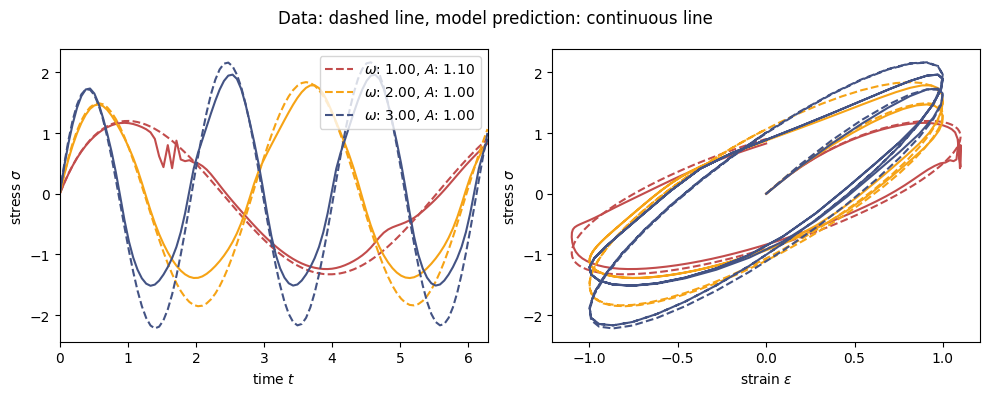

Plotte Relaxation Test...


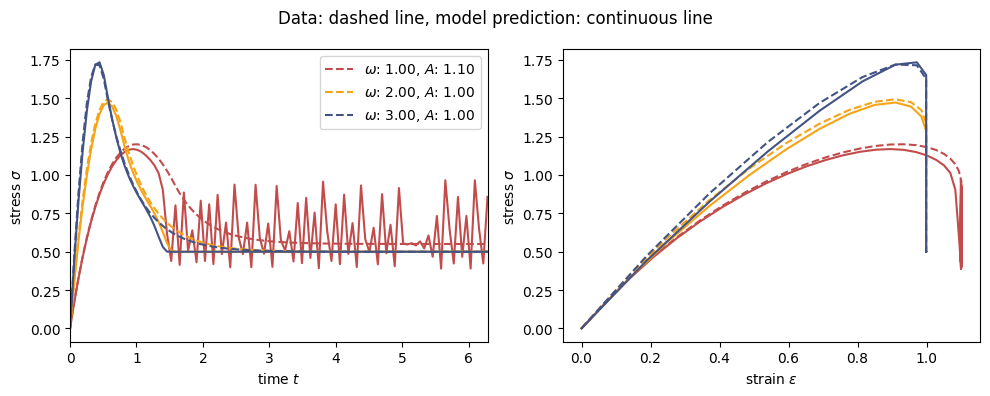

In [2]:
# filename = "artifacts\maxwell_nn__train_steps_sweep_steps_10000__10000steps__100ts__20260130_164306.eqx"
# filename = "artifacts\maxwell_nn__train_steps_sweep_steps_20000__20000steps__100ts__20260130_164335.eqx"
# filename = "artifacts\maxwell_nn__train_steps_sweep_steps_30000__30000steps__100ts__20260130_164419.eqx"
filename = "artifacts\maxwell_nn__train_steps_sweep_steps_100000__100000steps__100ts__20260130_165617.eqx"
plots.plot_saved_model(filename)

---
## Modell 2: Maxwell-Modell

### 2a) Analytisches Maxwell-Modell (nicht trainierbar)

Feste Gleichungen:
- $e(\varepsilon, \gamma) = \frac{1}{2} E^\infty \varepsilon^2 + \frac{1}{2} E (\varepsilon - \gamma)^2$
- $\sigma = E^\infty \varepsilon + E(\varepsilon - \gamma)$
- $\dot{\gamma} = \frac{E}{\eta}(\varepsilon - \gamma)$

In [7]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3]
As_test = [1, 1, 2]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)

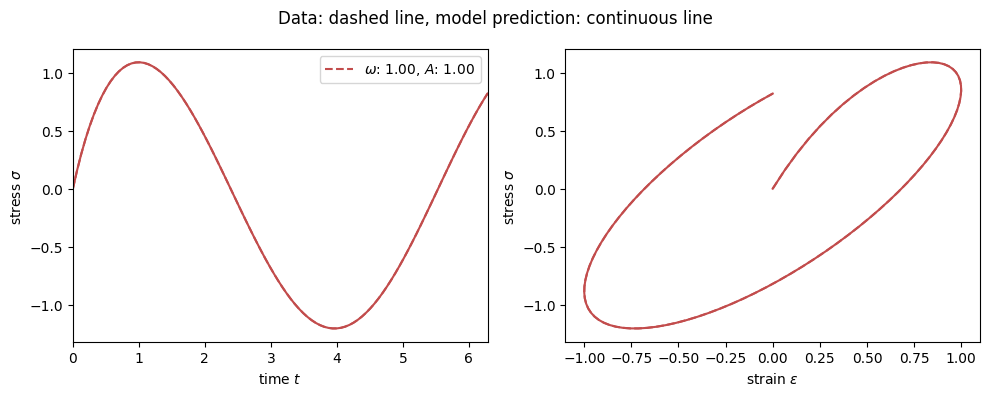

In [8]:
# Analytical Maxwell model (no training needed)
model_maxwell = tm.build_maxwell(E_infty=E_infty, E_val=E, eta=eta)

# Test on calibration data
sig_maxwell_cal = jax.vmap(model_maxwell)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_maxwell_cal, omegas_cal, As_cal)

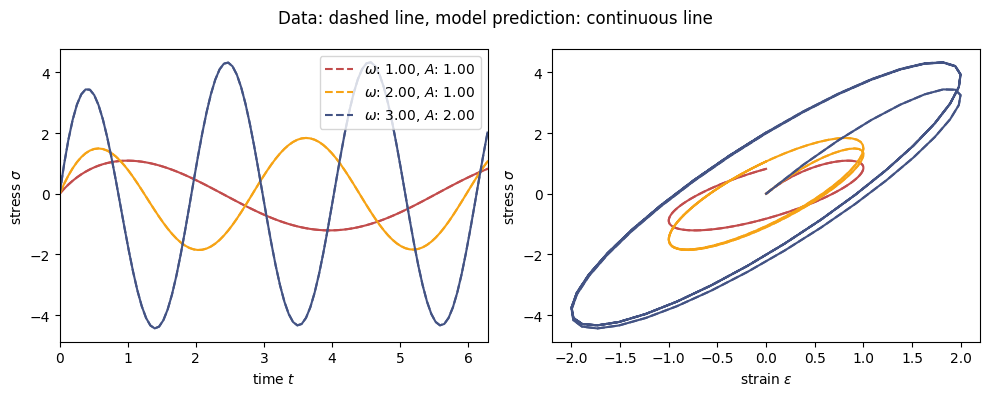

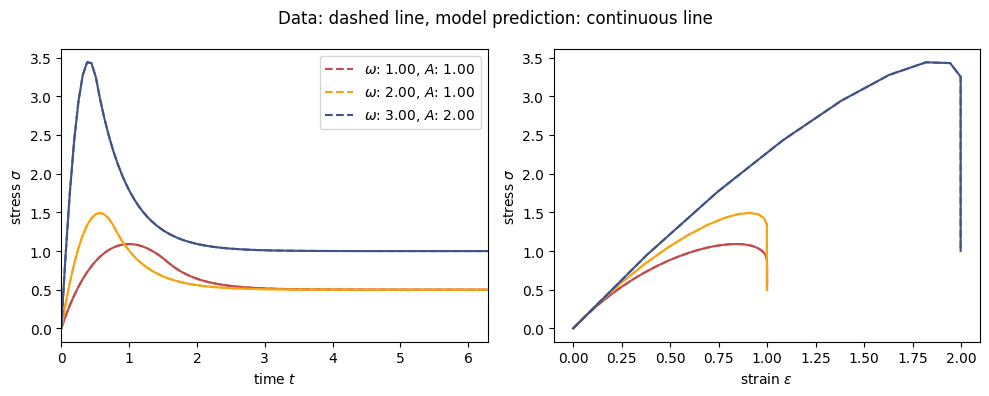

In [9]:
# Test on all load cases + relaxation
sig_maxwell_all = jax.vmap(model_maxwell)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_maxwell_all, omegas_test, As_test)

sig_maxwell_relax = jax.vmap(model_maxwell)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_maxwell_relax, omegas_test, As_test)

### 2b) Maxwell-Modell mit NN Evolutionsgleichung

Step: 0, Loss: 6.907e-01
Step: 100, Loss: 2.820e-03
Step: 200, Loss: 8.803e-04
Step: 300, Loss: 4.252e-04
Step: 400, Loss: 2.551e-04
Step: 500, Loss: 1.968e-04
Step: 600, Loss: 1.701e-04
Step: 700, Loss: 1.504e-04
Step: 800, Loss: 1.328e-04
Step: 900, Loss: 1.166e-04
Step: 1000, Loss: 1.019e-04
Step: 1100, Loss: 8.866e-05
Step: 1200, Loss: 7.691e-05
Step: 1300, Loss: 6.659e-05
Step: 1400, Loss: 5.760e-05
Step: 1500, Loss: 4.982e-05
Step: 1600, Loss: 4.309e-05
Step: 1700, Loss: 3.730e-05
Step: 1800, Loss: 3.229e-05
Step: 1900, Loss: 2.796e-05
Step: 2000, Loss: 2.419e-05
Step: 2100, Loss: 2.091e-05
Step: 2200, Loss: 1.802e-05
Step: 2300, Loss: 1.549e-05
Step: 2400, Loss: 1.325e-05
Step: 2500, Loss: 1.130e-05
Step: 2600, Loss: 9.584e-06
Step: 2700, Loss: 8.097e-06
Step: 2800, Loss: 6.818e-06
Step: 2900, Loss: 5.729e-06
Step: 3000, Loss: 4.814e-06
Step: 3100, Loss: 4.053e-06
Step: 3200, Loss: 3.430e-06
Step: 3300, Loss: 2.926e-06
Step: 3400, Loss: 2.521e-06
Step: 3500, Loss: 2.200e-06
Step

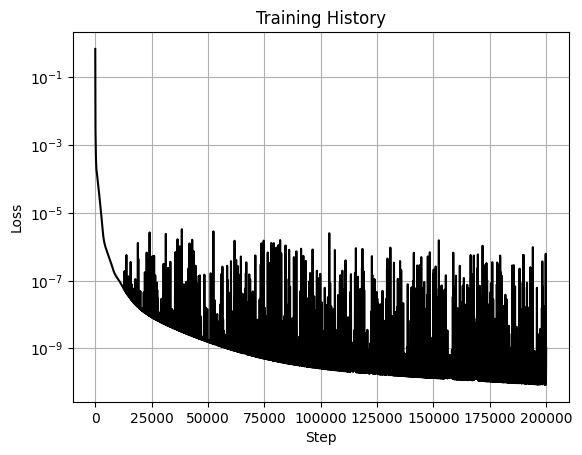

In [10]:
# Build and train Maxwell model with NN evolution equation
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_mnn = tm.build_maxwell_nn(key=keys[0], E_infty=E_infty, E_val=E)

model_mnn, history_mnn = klax.fit(
    model_mnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=200000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_mnn.plot()

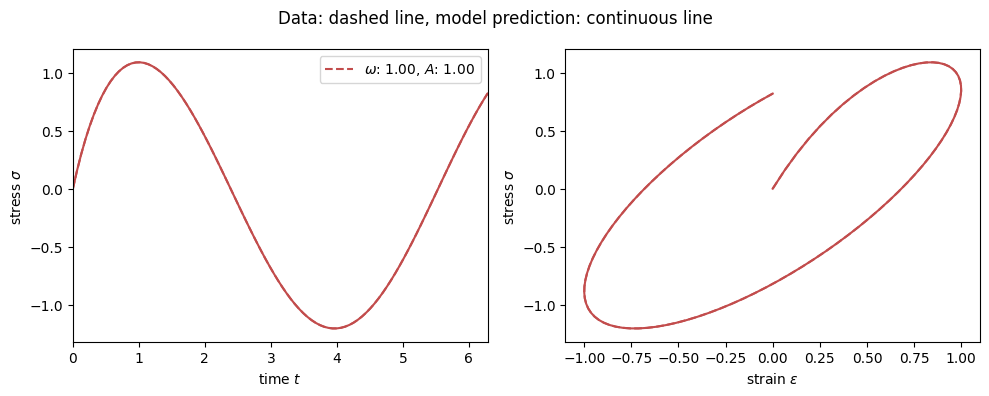

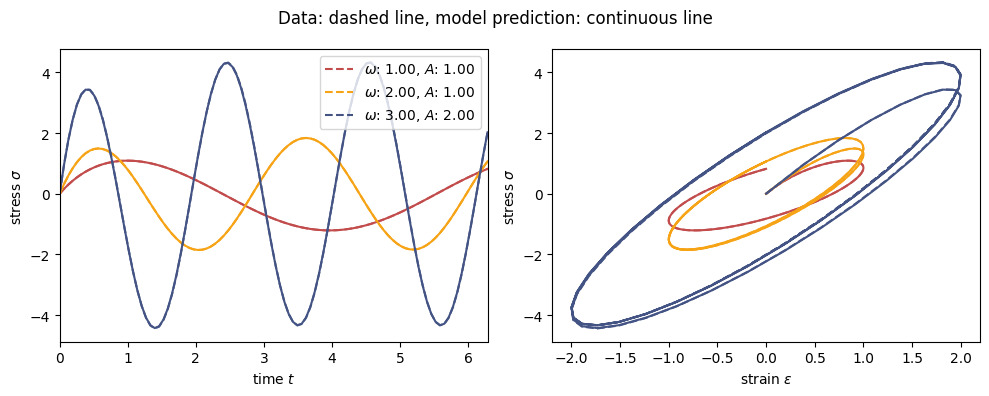

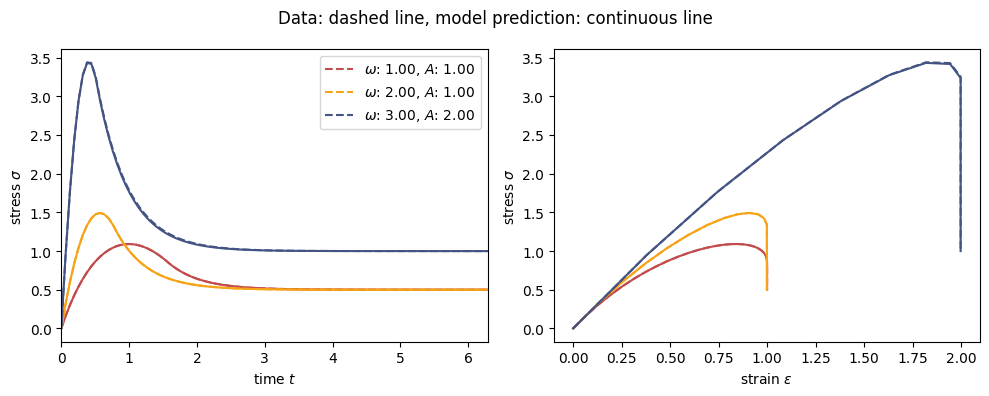

In [11]:
model_mnn_ = klax.finalize(model_mnn)

# Interpolation
sig_mnn_cal = jax.vmap(model_mnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_mnn_cal, omegas_cal, As_cal)

# Extrapolation
sig_mnn_test = jax.vmap(model_mnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_mnn_test, omegas_test, As_test)

# Relaxation
sig_mnn_relax = jax.vmap(model_mnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_mnn_relax, omegas_test, As_test)

---
## Modell 3: GSM-Modell (Generalized Standard Materials)

- $e = e(\varepsilon, \gamma)$ durch FFNN
- $\sigma = \frac{\partial e}{\partial \varepsilon}$
- $\dot{\gamma} = -g \cdot \frac{\partial e}{\partial \gamma}$, mit $g = \eta^{-1} = 1$

Step: 0, Loss: 1.244e+00
Step: 100, Loss: 2.125e-01
Step: 200, Loss: 1.099e-01
Step: 300, Loss: 4.977e-02
Step: 400, Loss: 2.409e-02
Step: 500, Loss: 1.143e-02
Step: 600, Loss: 6.376e-03
Step: 700, Loss: 3.225e-03
Step: 800, Loss: 1.536e-03
Step: 900, Loss: 7.382e-04
Step: 1000, Loss: 3.388e-04
Step: 1100, Loss: 1.932e-04
Step: 1200, Loss: 1.385e-04
Step: 1300, Loss: 1.669e-04
Step: 1400, Loss: 1.072e-04
Step: 1500, Loss: 1.733e-04
Step: 1600, Loss: 9.724e-05
Step: 1700, Loss: 3.912e-04
Step: 1800, Loss: 8.980e-05
Step: 1900, Loss: 9.508e-05
Step: 2000, Loss: 8.264e-05
Step: 2100, Loss: 7.906e-05
Step: 2200, Loss: 7.569e-05
Step: 2300, Loss: 7.234e-05
Step: 2400, Loss: 7.554e-05
Step: 2500, Loss: 6.610e-05
Step: 2600, Loss: 6.933e-05
Step: 2700, Loss: 6.060e-05
Step: 2800, Loss: 5.862e-05
Step: 2900, Loss: 5.578e-05
Step: 3000, Loss: 6.617e-05
Step: 3100, Loss: 5.157e-05
Step: 3200, Loss: 2.194e-04
Step: 3300, Loss: 4.781e-05
Step: 3400, Loss: 4.996e-05
Step: 3500, Loss: 4.456e-05
Step

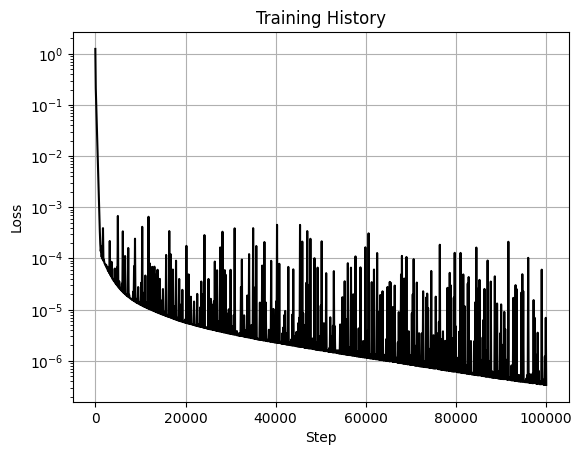

In [24]:
# Build and train GSM model
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_gsm = tm.build_gsm(key=keys[0], g=1.0 / eta)

model_gsm, history_gsm = klax.fit(
    model_gsm,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=100000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_gsm.plot()

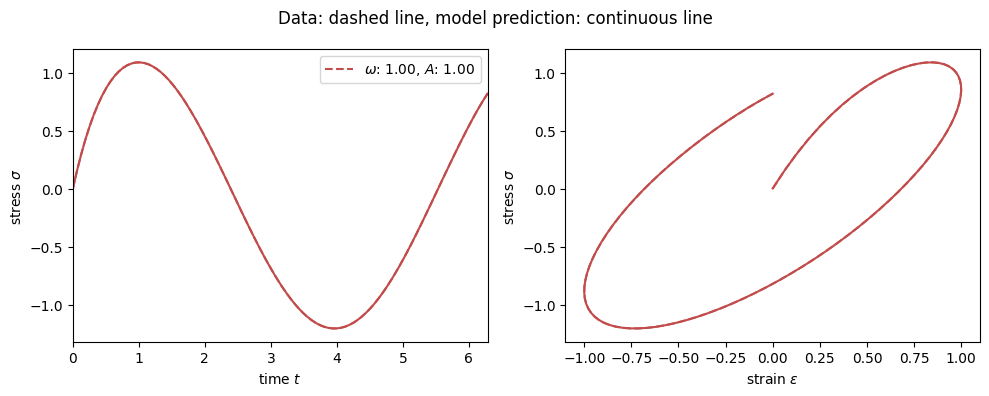

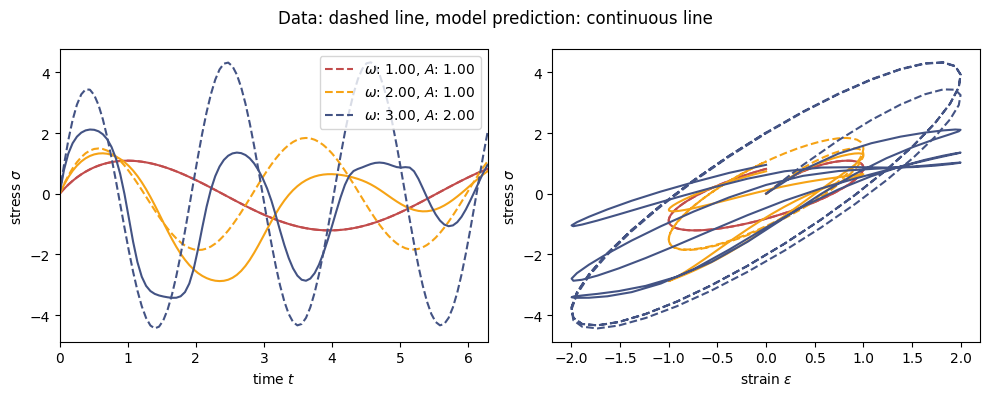

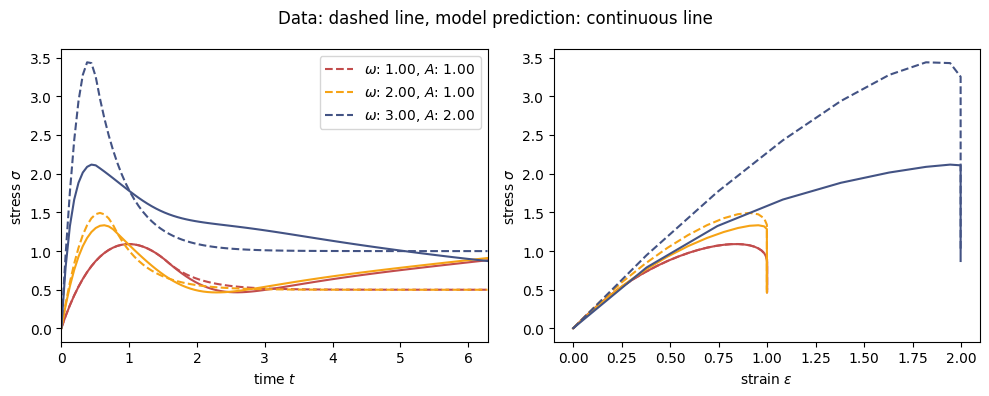

In [25]:
model_gsm_ = klax.finalize(model_gsm)

# Interpolation
sig_gsm_cal = jax.vmap(model_gsm_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_gsm_cal, omegas_cal, As_cal)

# Extrapolation
sig_gsm_test = jax.vmap(model_gsm_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_gsm_test, omegas_test, As_test)

# Relaxation
sig_gsm_relax = jax.vmap(model_gsm_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_gsm_relax, omegas_test, As_test)

---
## Experiment Framework: Timestep Resolution Study

Systematic comparison of model performance across different temporal resolutions:
- **Coarse (n=50)**: Fewer timesteps per period
- **Baseline (n=100)**: Standard resolution  
- **Fine (n=200)**: Higher temporal resolution

This helps understand how time discretization affects model accuracy.

---
## Evaluation:


In [ ]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3]
As_test = [1, 1, 2]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)

# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)

For all models it would be interesting to plot the energy and the dissipation if available in some way.

### Simple RNN (naive, no physics)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
{\gamma_{n+1}, \sigma_n}
=
\mathcal{C}_\theta(\gamma_n, \varepsilon_n, \Delta t_n)
$$

Here, $\mathcal{C}_\theta$ is a feed-forward neural network (the recurrent cell).

- **NN-computed:** $\gamma_{n+1}$ and $\sigma_n$
- **Analytical / physics:** none (beyond recurrence structure)


Evaluate only stress predictions directly since there are no internal variables to check.

In [ ]:
key = jrandom.PRNGKey(0)
model_rnn = tm.build(key=key)

# simulate batch (get gamma + sig)
gamma_rnn, sig_rnn = ev.simulate_model_batch(model_rnn, eps_test, dts_test)

# metrics
m_per_case = ev.compute_metrics_per_case(sig_test, sig_rnn)
print(ev.summarize_metrics(m_per_case))

# plot comparison vs ground truth
ev.plot_multi_model_predictions(
    eps_test, sig_test,
    {"simple_rnn": sig_rnn},
    omegas_test, As_test,
    title="Simple RNN vs ground truth"
)

# stress error plots
ev.plot_error_vs_time(sig_test, sig_rnn)
ev.plot_abs_error_vs_strain(eps_test, sig_test, sig_rnn)
ev.plot_abs_error_vs_strain_rate(eps_dot_test, sig_test, sig_rnn)

# dissipation proxy: hysteresis loop area per case
areas = ev.hysteresis_area_batch(eps_test, sig_rnn)
print("RNN hysteresis areas:", areas)


### Analytical Maxwell model

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e(\varepsilon,\gamma)
=
\frac{1}{2}E^\infty \varepsilon^2
+
\frac{1}{2}E(\varepsilon-\gamma)^2
$$

$$
\sigma_n
=
E^\infty \varepsilon_n
+
E(\varepsilon_n-\gamma_n)
$$

$$
\dot{\gamma}
=
\frac{E}{\eta}(\varepsilon-\gamma)
$$

$$
\gamma_{n+1}
=
\gamma_n
+
\Delta t_n\,\frac{E}{\eta}(\varepsilon_n-\gamma_n)
\quad \text{(explicit Euler)}
$$

- **NN-computed:** none  
- **Analytical / physics:** $\gamma_{n+1}$ and $\sigma_n$ from fixed $(E^\infty,E,\eta)$


Doesnt require treatment since its exactly = ground truth, unless we want to use it to access internal variables for comparison in other model evals.

In [ ]:
E_infty, E, eta = 0.5, 2.0, 1.0
model_maxwell = tm.build_maxwell(E_infty=E_infty, E_val=E, eta=eta)

gamma_mx, sig_mx = ev.simulate_model_batch(model_maxwell, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_mx)))

# energy + dissipation for loadcase 0
case = 0
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)

e = ev.maxwell_energy(eps_test[case], gamma_mx[case], E_infty, E)
D = ev.maxwell_dissipation_density(eps_test[case], gamma_mx[case], E, eta)

ev.plot_energy_and_dissipation(ts, {"maxwell": e}, {"maxwell": D}, title="Maxwell energy & dissipation (case 0)")


### Maxwell model with NN-based evolution (hybrid)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e(\varepsilon,\gamma)
=
\frac{1}{2}E^\infty \varepsilon^2
+
\frac{1}{2}E(\varepsilon-\gamma)^2
$$

$$
\sigma_n
=
E^\infty \varepsilon_n
+
E(\varepsilon_n-\gamma_n)
$$

$$
\dot{\gamma}
=
f_\theta(\varepsilon,\gamma)\,(\varepsilon-\gamma),
\qquad
f_\theta(\varepsilon,\gamma) > 0
$$

$$
\gamma_{n+1}
=
\gamma_n
+
\Delta t_n\,f_\theta(\varepsilon_n,\gamma_n)(\varepsilon_n-\gamma_n)
\quad \text{(explicit Euler)}
$$

- **NN-computed:** $f_\theta(\varepsilon_n,\gamma_n)$  
- **Analytical / physics:** stress $\sigma_n$ (Maxwell formula) and Euler update using NN output


Should consider separately evaluating NN predictions and internal variables to trace errors if necessary.

In [ ]:
key = jrandom.PRNGKey(1)
model_mxnn = tm.build_maxwell_nn(key=key, E_infty=0.5, E_val=2.0)

gamma_mxnn, sig_mxnn = ev.simulate_model_batch(model_mxnn, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_mxnn)))

# Inspect learned f_theta along trajectory (case 0)
case = 0
f_vals = ev.maxwell_nn_f(model_mxnn, eps_test[case], gamma_mxnn[case])

# Dissipation density (requires E)
D = ev.maxwell_nn_dissipation_density(model_mxnn, eps_test[case], gamma_mxnn[case], E=2.0)

# Plot f and D
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)
plt.figure(figsize=(10,3))
plt.plot(ts, f_vals)
plt.title("Maxwell+NN: learned f_theta along trajectory (case 0)")
plt.xlabel("t"); plt.ylabel("f_theta"); plt.show()

plt.figure(figsize=(10,3))
plt.plot(ts, D)
plt.title("Maxwell+NN: dissipation density D(t) (case 0)")
plt.xlabel("t"); plt.ylabel("D"); plt.show()


### GSM model (learned energy, physics via gradients)

**State:** {$\gamma_n \in \mathbb{R}$}  
**Inputs:** {$x_n = (\varepsilon_n,\Delta t_n)$}

$$
e_\theta = e_\theta(\varepsilon,\gamma),
\qquad
g > 0
$$

$$
\sigma_n
=
\frac{\partial e_\theta(\varepsilon_n,\gamma_n)}{\partial \varepsilon}
$$

$$
\dot{\gamma}
=
-\,g\,\frac{\partial e_\theta(\varepsilon,\gamma)}{\partial \gamma}
$$

$$
\gamma_{n+1}
=
\gamma_n
-
\Delta t_n\,g\,
\frac{\partial e_\theta(\varepsilon_n,\gamma_n)}{\partial \gamma}
\quad \text{(explicit Euler)}
$$

- **NN-computed:** energy potential $e_\theta(\varepsilon,\gamma)$  
- **Analytical / physics:** $\sigma_n$ and $\dot{\gamma}$ via autodiff gradients, Euler integration for $\gamma$


In [ ]:
key = jrandom.PRNGKey(2)
g = 1.0 / 1.0  # = 1/eta
model_gsm = tm.build_gsm(key=key, g=g)

gamma_gsm, sig_gsm = ev.simulate_model_batch(model_gsm, eps_test, dts_test)

# metrics
print(ev.summarize_metrics(ev.compute_metrics_per_case(sig_test, sig_gsm)))

# Energy + dissipation for case 0
case = 0
T = eps_test.shape[1]
ts = np.linspace(0, 2*np.pi, T)

e = ev.gsm_energy(model_gsm, eps_test[case], gamma_gsm[case])
D = ev.gsm_dissipation_density(model_gsm, eps_test[case], gamma_gsm[case])

ev.plot_energy_and_dissipation(ts, {"gsm": e}, {"gsm": D}, title="GSM energy & dissipation (case 0)")

### Compare multiple models

In [ ]:
# build / load models as above
models = {
    "simple_rnn": model_rnn,
    "maxwell": model_maxwell,
    "maxwell_nn": model_mxnn,
    "gsm": model_gsm,
}

sig_pred_by_model = {}
for name, mdl in models.items():
    _, sig_b = ev.simulate_model_batch(mdl, eps_test, dts_test)
    sig_pred_by_model[name] = sig_b

ev.plot_multi_model_predictions(
    eps_test, sig_test,
    sig_pred_by_model,
    omegas_test, As_test,
    title="All models vs ground truth"
)


# Load a saved model

## Simple RNN

In [ ]:
import jax.random as jrandom
from load_model import load_eqx_model
from tmlsm import models as tm

key = jrandom.PRNGKey(0)

model_rnn = load_eqx_model(
    build_fn=tm.build,
    checkpoint_path="checkpoints/simple_rnn.eqx",
    key=key,
)


## Maxwell + NN

In [ ]:
model_mxnn = load_eqx_model(
    build_fn=tm.build_maxwell_nn,
    checkpoint_path="checkpoints/maxwell_nn.eqx",
    key=key,
    E_infty=0.5,
    E_val=2.0,
)


## GSM

In [ ]:
model_gsm = load_eqx_model(
    build_fn=tm.build_gsm,
    checkpoint_path="checkpoints/gsm.eqx",
    key=key,
    g=1.0,   # must match training
)
